(perm_income_cons)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`永久收入 II：线性二次方法 <single: Permanent Income II: LQ Techniques>`

```{index} single: Models; Permanent Income
```

```{contents} 目录
:depth: 2
```

除了Anaconda中已有的库外，本讲座还需要以下库：

In [1]:
!pip install quantecon

## 概述

本讲座继续分析储蓄和消费的线性二次（LQ）永久收入模型。

正如我们在{doc}`上一讲<perm_income>`中所看到的，Robert Hall {cite}`Hall1978`使用LQ永久收入模型来限制和解释非耐用品消费、非金融收入和金融财富的跨期协动关系。

例如，我们看到该模型表明，对于任何协方差平稳的非金融收入过程：

- 消费是一个随机游走过程
- 金融财富具有单位根，并与消费存在协整关系

其他应用也使用相同的LQ框架。

例如，Robert Barro {cite}`Barro1979`使用了一个与LQ永久收入模型同构的模型，来解释政府税收、扣除债务服务后的支出以及公共债务之间的跨期协动关系。

这种同构意味着在分析LQ永久收入模型时，我们实际上也在分析Barro税收平滑模型。

这只是需要适当地重新标记Hall模型中的变量。

在本讲中，我们将：

* 展示如何使用LQ控制方法获得LQ永久收入模型的解。
* 将模型表示为线性状态空间系统，如{doc}`本讲<linear_models>`所示。
* 应用[QuantEcon](https://quantecon.org/quantecon-py/)的[LinearStateSpace](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lss.py)类来描述消费者最优消费和借贷计划的统计特征。

然后，我们将使用这些特征来构建一个简单的横截面财富和消费动态模型，这是按照Truman Bewley {cite}`Bewley86`的思路进行的。

（稍后我们将研究其他Bewley模型——参见{doc}`本讲<aiyagari>`。）

该模型将有助于说明以下概念：

* 平稳性
* 遍历性
* 集合矩和横截面观测

让我们从导入开始：

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

plt.rcParams["figure.figsize"] = (11, 5)  #设置默认图形大小
import quantecon as qe
import numpy as np
import scipy.linalg as la

## 设置

让我们回顾一下在{doc}`永久收入模型 <perm_income>`中讨论的模型基本特征。

消费者的偏好由以下式子排序

```{math}
:label: old1

E_0 \sum_{t=0}^\infty \beta^t u(c_t)
```

其中 $u(c) = -(c - \gamma)^2$。

消费者通过选择消费和借贷计划 $\{c_t, b_{t+1}\}_{t=0}^\infty$ 来最大化 {eq}`old1`，
受到一系列预算约束

```{math}
:label: old2

c_t + b_t = \frac{1}{1 + r} b_{t+1}  + y_t,
\quad t \geq 0
```

以及无庞氏条件

```{math}
:label: old42

E_0 \sum_{t=0}^\infty \beta^t b_t^2 < \infty
```

所有变量和参数的解释与{doc}`上一讲 <perm_income>`中相同。

我们继续假设 $(1 + r) \beta = 1$。

$\{y_t\}$ 的动态仍然遵循线性状态空间模型

```{math}
:label: sprob15ab2

\begin{aligned}
    z_{t+1} & = A z_t + C w_{t+1}
    \\
    y_t & = U  z_t
\end{aligned}
```

对冲击过程和参数的限制与我们{doc}`之前的讲座 <perm_income>`中的相同。

### 关于一个有用同构的补充说明

消费的LQ永久收入模型在数学上与Barro的{cite}`Barro1979`税收平滑模型的一个版本是同构的。

在LQ永久收入模型中：

* 家庭面临非金融收入的外生过程
* 家庭希望在不同状态和时间中平滑消费

在Barro税收平滑模型中：

* 政府面临政府购买的外生序列（扣除其债务利息支付）
* 政府希望在不同状态和时间中平滑税收

如果我们设：

* $T_t$，Barro模型中的总税收对应LQ永久收入模型中的消费$c_t$。
* $G_t$，Barro模型中的外生政府支出对应永久收入模型中的非金融收入$y_t$。
* $B_t$，Barro模型中到期的政府无风险一期资产对应于LQ永久收入模型中到期的无风险一期消费者债务$b_t$。
* $R$，Barro模型中无风险一期政府债务的总回报率对应于永久收入消费模型中金融资产的总回报率$1+r$。

那么这两个模型在数学上是等价的。

LQ永久收入模型中对$\{c_t, y_t, b_t\}$的所有特征描述自动适用于Barro税收平滑模型中的$\{T_t, G_t, B_t\}$过程。

关于消费和税收平滑模型之间的同构性的进一步探讨，请参见[消费和税收平滑模型](https://python-advanced.quantecon.org/smoothing.html)。

### 非金融收入过程的具体说明

在本讲中，我们假设$\{y_t\}$是一个二阶单变量自回归过程：

$$
y_{t+1} = \alpha + \rho_1 y_t + \rho_2 y_{t-1} + \sigma w_{t+1}
$$

我们可以将其映射到{eq}`sprob15ab2`中的线性状态空间框架中，正如我们在{doc}`线性模型 <linear_models>`讲座中所讨论的。

为此，我们取

$$
z_t =
\begin{bmatrix}
    1 \\
    y_t \\
    y_{t-1}
\end{bmatrix},
\quad
A = \begin{bmatrix}
          1 & 0 & 0 \\
          \alpha & \rho_1 & \rho_2  \\
          0 & 1 & 0
    \end{bmatrix},
\quad
C= \begin{bmatrix}
    0 \\
    \sigma \\
    0
    \end{bmatrix},
\quad \text{和} \quad
U = \begin{bmatrix} 0 & 1 & 0 \end{bmatrix}
$$

## LQ方法

{ref}`此前 <odr_pi>`我们通过求解受两个边界条件约束的线性期望差分方程组来解决永久收入模型。

这里我们使用基于动态规划的{doc}`LQ方法 <lqcontrol>`来解决相同的模型。

在确认两种方法得出的答案一致后，我们使用[QuantEcon](https://quantecon.org/quantecon-py/)的[LinearStateSpace](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lss.py)类来展示模型的特点。

为什么要用两种不同的方法来求解模型？

因为这样做可以让我们更深入地理解模型的结构。

我们之前基于求解期望差分方程组的方法突出了消费者对未来非金融收入的预期所起的作用。

另一方面，将模型表述为LQ动态规划问题提醒我们：

- 找到(动态规划问题的)状态是一门艺术，并且
- 对贝尔曼方程的迭代隐含地同时解决了预测问题和控制问题

### LQ问题

回顾我们在{doc}`LQ理论讲座<lqcontrol>`中提到，最优线性调节器问题是要选择
用于最小化

$$
\mathbb E
\sum_{t=0}^\infty \beta^t \{x'_t R x_t+ u'_t Q u_t\},
$$

的决策规则 $u_t$，

受限于给定的 $x_0$ 和运动方程

```{math}
:label: pilqsd

x_{t+1} =  \tilde A x_t+ \tilde B u_t+ \tilde C w_{t+1},
\qquad t\geq 0,
```

其中 $w_{t+1}$ 是独立同分布的，均值向量为零且 $\mathbb E w_t w'_t= I$。

$\tilde A, \tilde B, \tilde C$ 中的波浪线是为了避免与{eq}`sprob15ab2`中的符号冲突。

这个问题的值函数是 $v(x) = - x'Px - d$，其中

* $P$ 是{ref}`相应矩阵黎卡提方程<riccati_equation>`的唯一半正定解。
* 标量 $d$ 由 $d=\beta (1-\beta)^{-1} {\rm trace} ( P \tilde C \tilde C')$ 给出。

最优策略是 $u_t = -Fx_t$，其中 $F := \beta (Q+\beta \tilde B'P \tilde B)^{-1} \tilde B'P \tilde A$。

在最优决策规则 $F$ 下，状态向量 $x_t$ 按照 $x_{t+1} = (\tilde A-\tilde BF) x_t + \tilde C w_{t+1}$ 演化。

### 映射到LQ框架

为了映射到LQ框架，我们将使用

$$
x_t :=
    \begin{bmatrix}
        z_t \\
        b_t
    \end{bmatrix} =
    \begin{bmatrix}
        1 \\
        y_t \\
        y_{t-1} \\
        b_t
    \end{bmatrix}
$$

作为状态向量，并将$u_t := c_t - \gamma$作为控制变量。

使用这个符号表示法，并且$U_\gamma := \begin{bmatrix} \gamma & 0 & 0
\end{bmatrix}$，我们可以将状态动态写成{eq}`pilqsd`的形式，其中

$$
\tilde A :=
     \begin{bmatrix}
        A  &  0 \\
        (1 + r)(U_\gamma - U) & 1 + r
     \end{bmatrix}
\quad
\tilde B :=
   \begin{bmatrix}
   0 \\
   1 + r
   \end{bmatrix}
\quad \text{和} \quad
\tilde C :=
   \begin{bmatrix}
   C \\ 0
   \end{bmatrix}
   w_{t+1}
$$

请自行确认，使用这些定义，LQ动态{eq}`pilqsd`与上述$z_t$和$b_t$的动态是匹配的。

为了将效用映射到二次形式$x_t' R x_t + u_t'Q u_t$，我们可以设置

* $Q := 1$（请记住我们在最小化）且
* $R :=$ 一个 $4 \times 4$ 的零矩阵

然而，还有一个问题待解决。

在LQ框架内，我们没有直接的方法来捕捉债务序列 $\{b_t\}$ 的非递归限制 {eq}`old42`。

为了尝试强制执行这一限制，我们将使用一个技巧：在目标函数中对 $b_t^2$ 添加一个小惩罚项。

在当前设置中，这意味着在 $R$ 矩阵的 $(4,4)$ 位置添加一个小的值 $\epsilon > 0$。

这将在决策规则中引入一个（希望是）小的近似误差。

我们很快就会通过数值计算来检验它是否真的很小。

## 实现

让我们编写一些代码来求解这个模型。

在开始之前需要说明的是，效用函数中的消费福利水平 $\gamma$ 对最优决策规则没有影响。

我们在前面的讲座 {doc}`permanent income <perm_income>` 中已经看到了这一点。

原因是它在消费的欧拉方程中被消去了。

在下文中我们将其设为1。

### 外生非金融收入过程

首先，我们为最优线性调节器创建对象

In [3]:
# 设置参数
α, β, ρ1, ρ2, σ = 10.0, 0.95, 0.9, 0.0, 1.0

R = 1 / β
A = np.array([[1., 0., 0.],
              [α,  ρ1, ρ2],
              [0., 1., 0.]])
C = np.array([[0.], [σ], [0.]])
G = np.array([[0., 1., 0.]])

# 构建LinearStateSpace系统并提取稳态矩
μ_z0 = np.array([[1.0], [0.0], [0.0]])
Σ_z0 = np.zeros((3, 3))
Lz = qe.LinearStateSpace(A, C, G, mu_0=μ_z0, Sigma_0=Σ_z0)
μ_z, μ_y, Σ_z, Σ_y, Σ_yx = Lz.stationary_distributions()

# 储蓄问题的状态均值向量
mxo = np.vstack([μ_z, 0.0])

# 创建x的稳态协方差矩阵 -- 所有人初始债务b=0
a1 = np.zeros((3, 1))
aa = np.hstack([Σ_z, a1])
bb = np.zeros((1, 4))
sxo = np.vstack([aa, bb])

# 这些选择将个体的状态向量初始化为零债务和
# 禀赋过程的遍历分布。使用这些来创建Bewley经济。
mxbewley = mxo
sxbewley = sxo

下一步是创建LQ系统的矩阵

In [4]:
A12 = np.zeros((3,1))
ALQ_l = np.hstack([A, A12])
ALQ_r = np.array([[0, -R, 0, R]])
ALQ = np.vstack([ALQ_l, ALQ_r])

RLQ = np.array([[0., 0., 0., 0.],
                [0., 0., 0., 0.],
                [0., 0., 0., 0.],
                [0., 0., 0., 1e-9]])

QLQ = np.array([1.0])
BLQ = np.array([0., 0., 0., R]).reshape(4,1)
CLQ = np.array([0., σ, 0., 0.]).reshape(4,1)
β_LQ = β

让我们把这些打印出来看看

In [5]:
print(f"A = \n {ALQ}")
print(f"B = \n {BLQ}")
print(f"R = \n {RLQ}")
print(f"Q = \n {QLQ}")

A = 
 [[ 1.          0.          0.          0.        ]
 [10.          0.9         0.          0.        ]
 [ 0.          1.          0.          0.        ]
 [ 0.         -1.05263158  0.          1.05263158]]
B = 
 [[0.        ]
 [0.        ]
 [0.        ]
 [1.05263158]]
R = 
 [[0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e-09]]
Q = 
 [1.]


现在创建一个适当的LQ模型实例

In [6]:
lqpi = qe.LQ(QLQ, RLQ, ALQ, BLQ, C=CLQ, beta=β_LQ)

我们很快会保存隐含的最优策略函数，并将其与使用其他求解方法得到的结果进行比较

In [7]:
P, F, d = lqpi.stationary_values()  # 计算值函数和决策规则
ABF = ALQ - BLQ @ F  # 构建闭环系统

### 与差分方程方法的比较

在我们关于无限期永久收入问题的{doc}`第一讲<perm_income>`中，我们使用了不同的解决方法。

该方法基于

* 推导出关于消费和储蓄的一阶条件的欧拉方程。
* 使用预算约束和边界条件来完成一个期望线性差分方程组。
* 求解这些方程以获得解。

用状态空间表示法表示，解的形式为

$$
\begin{aligned}
    z_{t+1} & = A z_t + C w_{t+1} \\
    b_{t+1} & = b_t + U [ (I -\beta A)^{-1} (A - I) ] z_t \\
        y_t & = U z_t \\
        c_t & = (1-\beta) [ U (I-\beta A)^{-1} z_t - b_t ]
\end{aligned}
$$

现在我们将应用这个系统中的公式

In [8]:
# 使用上述公式创建b_{t+1}和c_t的最优策略
b_pol = G @ la.inv(np.eye(3, 3) - β * A) @ (A - np.eye(3, 3))
c_pol = (1 - β) * G @ la.inv(np.eye(3, 3) - β * A)

# 为LinearStateSpace实例创建A矩阵
A_LSS1 = np.vstack([A, b_pol])
A_LSS2 = np.eye(4, 1, -3)
A_LSS = np.hstack([A_LSS1, A_LSS2])

# 为LSS方法创建C矩阵
C_LSS = np.vstack([C, np.zeros(1)])

# 为LSS方法创建G矩阵
G_LSS1 = np.vstack([G, c_pol])
G_LSS2 = np.vstack([np.zeros(1), -(1 - β)])
G_LSS = np.hstack([G_LSS1, G_LSS2])

# 使用以下值使每个人从b=0开始，初始收入为零
μ_0 = np.array([1., 0., 0., 0.])
Σ_0 = np.zeros((4, 4))

使用这里的方法计算的`A_LSS`应该等于上面用LQ模型计算的`ABF`

In [9]:
ABF - A_LSS

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-9.51248261e-06,  9.51247857e-08,  0.00000000e+00,
        -1.99999919e-08]])

现在比较 `c_pol` 和 `F` 的相关元素

In [10]:
print(c_pol, "\n", -F)

[[65.51724138  0.34482759  0.        ]] 
 [[ 6.55172323e+01  3.44827677e-01 -0.00000000e+00 -5.00000190e-02]]


我们已经验证了两种方法得出相同的解。

现在让我们创建[LinearStateSpace](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lss.py)类的实例,并用它来做一些有趣的实验。

为此,我们将使用第二种方法的结果。

## 两个经济示例

本着Bewley模型{cite}`Bewley86`的精神,我们将生成消费者面板数据。

这两个示例仅在赋予消费者的初始状态上有所不同。

所有其他参数值在两个示例中保持相同

- 在第一个示例中,所有消费者的初始非金融收入和债务都为零。
    * 因此消费者在事前是相同的。
- 在第二个示例中,虽然所有人的初始债务都为零,但我们从金融收入的不变分布中抽取他们的初始收入水平。
    * 消费者在事前是异质的。

在第一个示例中,消费者的非金融收入路径显示
样本早期的明显瞬态

- 这些会以显著方式影响结果

第二个例子中不会出现这些瞬态效应。

我们使用与[LinearStateSpace](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lss.py)类相关的方法来模拟该模型。

### 第一组初始条件

我们生成25条外生非金融收入过程的路径以及相应的最优消费和债务路径。

在第一组图中，深色线条描绘了一条特定的样本路径，而浅色线条描述了其他24条路径。

第二张图将一组模拟结果与我们从`LinearStateSpace`实例`LSS`中提取的总体分布进行对比。

在每个时间点$t$比较样本路径与总体分布是一个有用的练习——参见{ref}`我们关于大数定律的讨论<lln_mr>`

In [11]:
lss = qe.LinearStateSpace(A_LSS, C_LSS, G_LSS, mu_0=μ_0, Sigma_0=Σ_0)

### 总体和样本面板

在下面的代码中，我们使用[LinearStateSpace](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lss.py)类来

- 计算并绘制一群消费者的消费和债务分布的总体分位数。
- 模拟25个消费者的群体，并在同一图表上绘制样本路径和总体分布。

In [12]:
def income_consumption_debt_series(A, C, G, μ_0, Σ_0, T=150, npaths=25):
    """
    该函数接收初始条件(μ_0, Σ_0)，并使用QuantEcon的LinearStateSpace类
    对一个经济体进行T期的npaths次模拟。然后使用这些信息生成一些与下述
    讨论相关的图表。
    """
    lss = qe.LinearStateSpace(A, C, G, mu_0=μ_0, Sigma_0=Σ_0)

    # 模拟/矩参数
    moment_generator = lss.moment_sequence()

    # 模拟各种路径
    bsim = np.empty((npaths, T))
    csim = np.empty((npaths, T))
    ysim = np.empty((npaths, T))

    for i in range(npaths):
        sims = lss.simulate(T)
        bsim[i, :] = sims[0][-1, :]
        csim[i, :] = sims[1][1, :]
        ysim[i, :] = sims[1][0, :]

    # 获取矩
    cons_mean = np.empty(T)
    cons_var = np.empty(T)
    debt_mean = np.empty(T)
    debt_var = np.empty(T)
    for t in range(T):
        μ_x, μ_y, Σ_x, Σ_y = next(moment_generator)
        cons_mean[t], cons_var[t] = μ_y[1,0], Σ_y[1, 1]
        debt_mean[t], debt_var[t] = μ_x[3,0], Σ_x[3, 3]

    return bsim, csim, ysim, cons_mean, cons_var, debt_mean, debt_var

def consumption_income_debt_figure(bsim, csim, ysim):

    # 获取T
    T =  bsim.shape[1]

    # 创建第一个图
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    xvals = np.arange(T)

    # 绘制消费和收入
    ax[0].plot(csim[0, :], label="c", color="b")
    ax[0].plot(ysim[0, :], label="y", color="g")
    ax[0].plot(csim.T, alpha=.1, color="b")
    ax[0].plot(ysim.T, alpha=.1, color="g")
    ax[0].legend(loc=4)
    ax[0].set(title="非金融收入、消费和债务",
              xlabel="t", ylabel="y和c")

    # 绘制债务
    ax[1].plot(bsim[0, :], label="b", color="r")
    ax[1].plot(bsim.T, alpha=.1, color="r")
    ax[1].legend(loc=4)
    ax[1].set(xlabel="t", ylabel="债务")

    fig.tight_layout()
    return fig

def consumption_debt_fanchart(csim, cons_mean, cons_var,
                              bsim, debt_mean, debt_var):
    # 获取T
    T =  bsim.shape[1]

    # 创建横截面分布的百分位数
    cmean = np.mean(cons_mean)
    c90 = 1.65 * np.sqrt(cons_var)
    c95 = 1.96 * np.sqrt(cons_var)
    c_perc_95p, c_perc_95m = cons_mean + c95, cons_mean - c95
    c_perc_90p, c_perc_90m = cons_mean + c90, cons_mean - c90

    # 创建横截面分布的百分位数
    dmean = np.mean(debt_mean)
    d90 = 1.65 * np.sqrt(debt_var)
    d95 = 1.96 * np.sqrt(debt_var)
    d_perc_95p, d_perc_95m = debt_mean + d95, debt_mean - d95
    d_perc_90p, d_perc_90m = debt_mean + d90, debt_mean - d90


    # 创建第二个图
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    xvals = np.arange(T)

    # 消费扇形图
    ax[0].plot(xvals, cons_mean, color="k")
    ax[0].plot(csim.T, color="k", alpha=.25)
    ax[0].fill_between(xvals, c_perc_95m, c_perc_95p, alpha=.25, color="b")
    ax[0].fill_between(xvals, c_perc_90m, c_perc_90p, alpha=.25, color="r")
    ax[0].set(title="消费/债务随时间变化",
              ylim=(cmean-15, cmean+15), ylabel="消费")

    # 债务扇形图
    ax[1].plot(xvals, debt_mean, color="k")
    ax[1].plot(bsim.T, color="k", alpha=.25)
    ax[1].fill_between(xvals, d_perc_95m, d_perc_95p, alpha=.25, color="b")
    ax[1].fill_between(xvals, d_perc_90m, d_perc_90p, alpha=.25, color="r")
    ax[1].set(xlabel="t", ylabel="债务")

    fig.tight_layout()
    return fig

现在让我们创建 $y_0$ 和 $b_0$ 的初始条件为零的图表

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


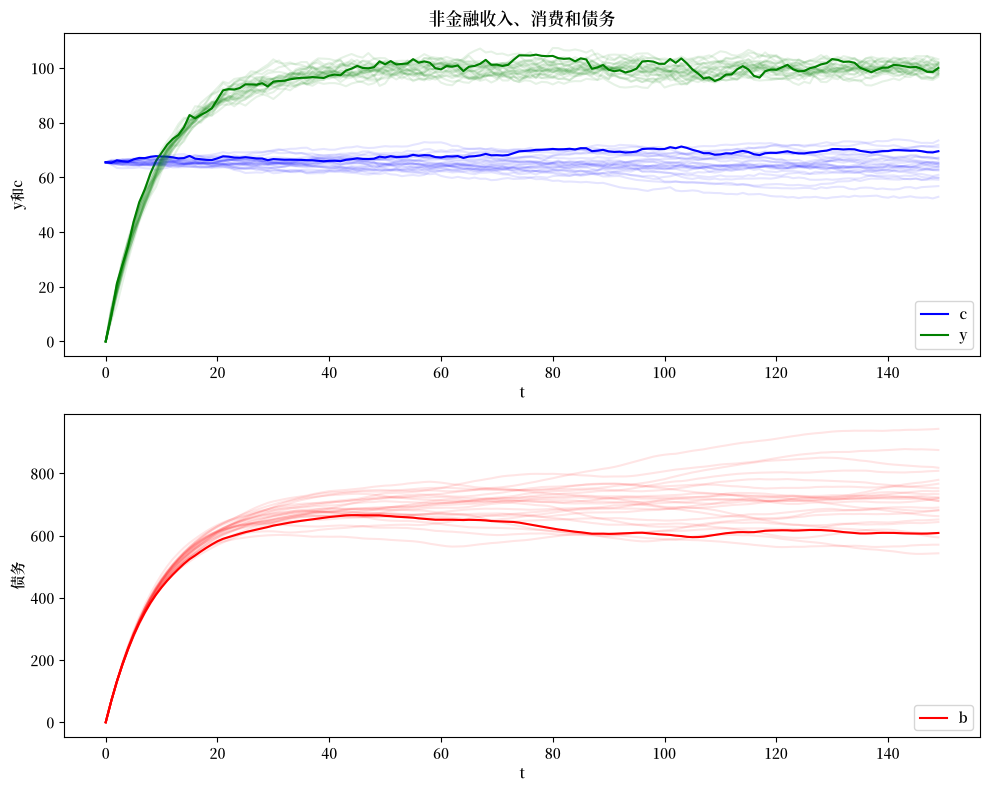

In [13]:
out = income_consumption_debt_series(A_LSS, C_LSS, G_LSS, μ_0, Σ_0)
bsim0, csim0, ysim0 = out[:3]
cons_mean0, cons_var0, debt_mean0, debt_var0 = out[3:]

consumption_income_debt_figure(bsim0, csim0, ysim0)

plt.show()

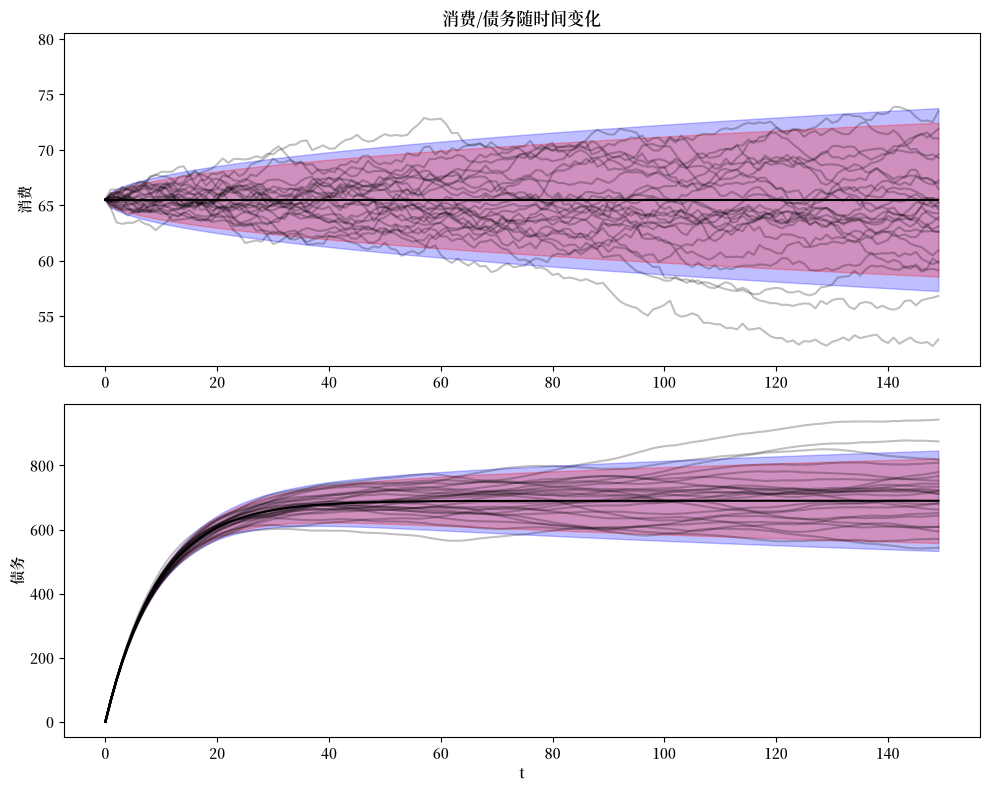

In [14]:
consumption_debt_fanchart(csim0, cons_mean0, cons_var0,
                          bsim0, debt_mean0, debt_var0)

plt.show()

以下是上述图表所显示的内容。

在我们的模拟中，我们设定了初始条件 $b_0 = y_{-1} = y_{-2} = 0$。

由于 $y_{-1} = y_{-2} = 0$，非金融收入 $y_t$ 在开始时远低于其稳态均值 $\mu_{y, \infty}$，并在每次模拟的早期阶段上升。

回顾{doc}`上一讲<perm_income>`，我们可以用**协整关系**来表示消费的最优决策规则

```{math}
:label: old12

(1-\beta) b_t + c_t = (1-\beta) E_t \sum_{j=0}^\infty \beta^j y_{t+j}
```

因此在时间 $0$ 时，我们有

$$
c_0 = (1-\beta) E_0 \sum_{t=0}^\infty \beta^j y_{t}
$$

这告诉我们，消费开始于一个年金所支付的收入水平，该年金的价值等于在时间 $t=0$ 时非金融收入的预期贴现值。

为了维持这个消费水平，消费者在早期大量借贷，因此积累了大量债务。

事实上，他/她积累了如此多的债务，以至于在随机稳态下，他每期的消费都低于其非金融收入。

他主要用消费和非金融收入之间的差额来支付债务的利息。

因此，当我们查看附图中的债务面板时，我们看到这是一群*事前*完全相同的人，他们每个人都是从零债务开始的。

他们都在预期非金融收入上升的情况下积累债务。

他们预计他们的非金融收入会上升到收入的不变分布，这是因为我们一开始将他们的收入设定为$y_{-1} = y_{-2} = 0$。

#### 协整残差

下图绘制了{eq}`old12`左侧的实现值，这在{ref}`我们上一讲中讨论过 <coint_pi>`，被称为**协整残差**。

如上所述，右侧可以被理解为未来收入预期现值的年金支付
$E_t \sum_{j=0}^\infty \beta^j y_{t+j}$。

在实现过程的早期，当家庭的收入现值和借款几乎同时上升时，$c_t$ 大致保持恒定，而$(1-\beta) b_t$和$(1-\beta) E_t \sum_{j=0}^\infty \beta^j y_{t+j}$都显著上升。

这个例子说明了以下观点：协整的定义意味着协整残差是*渐近*协方差平稳的，而不是*协方差平稳*的。

对于初始收入和债务为零的规格，其协整残差在样本早期有一个显著的暂时性成分主导其行为。

通过改变初始条件，我们将在下面要展示的第二个例子中消除这种暂时性成分。

In [15]:
def cointegration_figure(bsim, csim):
    """
    绘制协整图
    """
    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot((1 - β) * bsim[0, :] + csim[0, :], color="k")
    ax.plot((1 - β) * bsim.T + csim.T, color="k", alpha=.1)

    ax.set(title="资产和消费的协整关系", xlabel="t")

    return fig

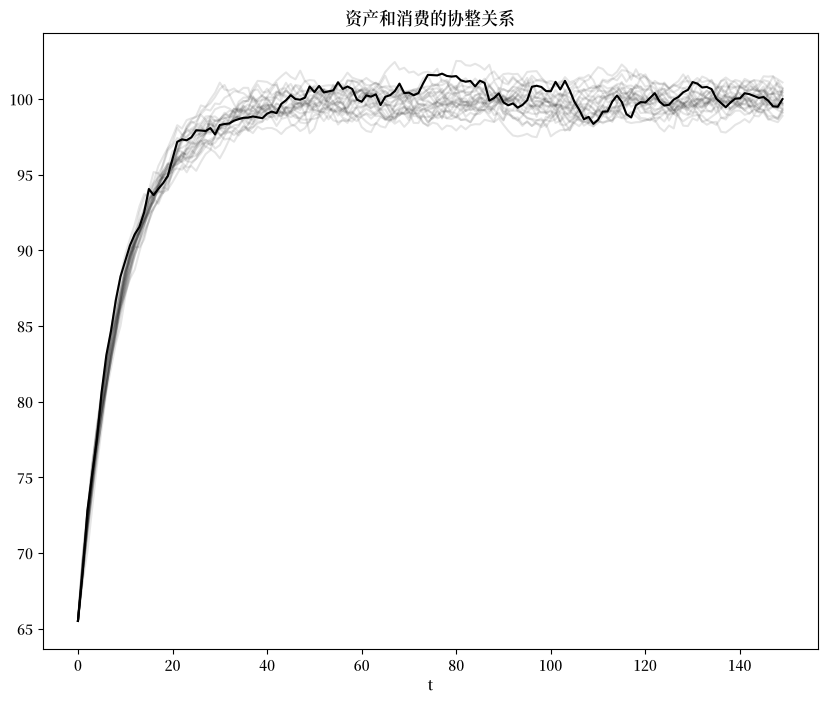

In [16]:
cointegration_figure(bsim0, csim0)
plt.show()

### "借贷者"封闭经济

当我们在前面的练习中设定 $y_{-1} = y_{-2} = 0$ 和 $b_0 =0$ 时，我们使债务在样本早期"向北"发展。

横截面的平均债务上升并接近渐近线。

我们可以将这些视为一个"小型开放经济"的结果，该经济以固定的总利率 $R = r+1$ 从国外借款，以预期收入上升。

因此，在上述经济基本要素的设定下，经济收敛到一个稳态，在该稳态下，在总利率 $R$ 时存在无风险贷款的总供给过剩。

这个供给过剩由愿意提供这些贷款的"外国贷款人"填补。

我们可以使用几乎相同的代码，通过以下方式构建一个"简化版的Bewley模型" {cite}`Bewley86`

- 和之前一样，我们让每个人从 $b_0 = 0$ 开始。
- 但是我们不是让每个人从 $y_{-1} = y_{-2} = 0$ 开始，而是从 $\{y_t\}$ 过程的不变分布中抽取 $\begin{bmatrix} y_{-1} \\ y_{-2}   \end{bmatrix}$。

这构建了一个封闭经济，其中人们以总无风险利率 $R = \beta^{-1}$ 相互借贷。

在被分析的群体中，无风险贷款的超额供给为零。

我们已经安排了基本要素，使得 $R = \beta^{-1}$ 在零总超额供给的水平上清算无风险贷款市场。

因此，无风险贷款是在我们这个封闭个体群体内部相互进行的。

不需要外国人向我们的群体提供贷款。

让我们看看相应的图表

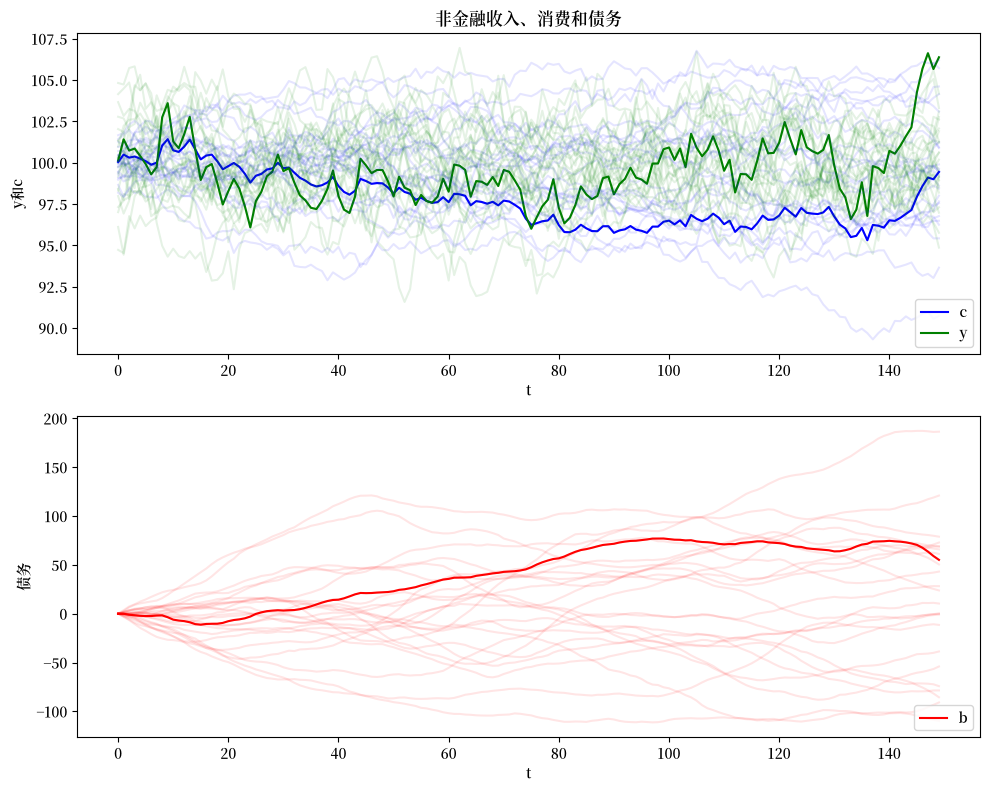

In [17]:
out = income_consumption_debt_series(A_LSS, C_LSS, G_LSS, mxbewley, sxbewley)
bsimb, csimb, ysimb = out[:3]
cons_meanb, cons_varb, debt_meanb, debt_varb = out[3:]

consumption_income_debt_figure(bsimb, csimb, ysimb)

plt.show()

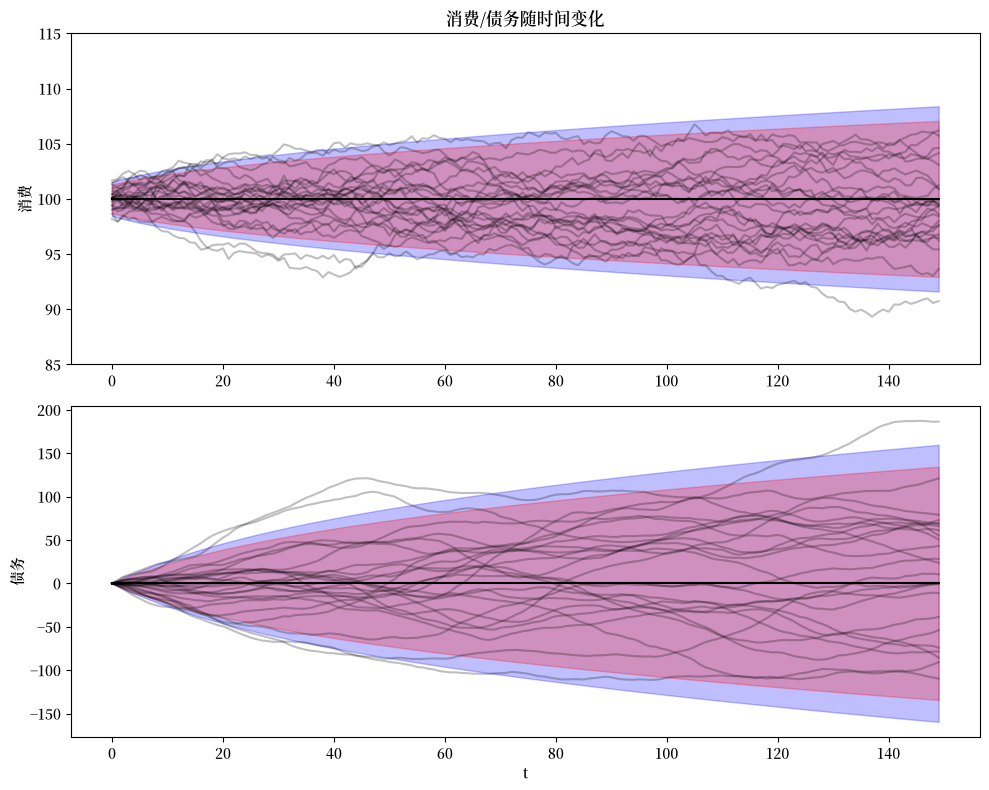

In [18]:
consumption_debt_fanchart(csimb, cons_meanb, cons_varb,
                          bsimb, debt_meanb, debt_varb)

plt.show()

图表确认了以下结果：

- 和之前一样，消费分布随时间扩散。

但现在由于在初始抽取 $\begin{bmatrix} y_{-1} \\ y_{-2}   \end{bmatrix}$ 时存在*事前*异质性，所以有一些初始分散。

- 和之前一样，债务的横截面分布随时间扩散。
- 与之前不同的是，债务的平均水平保持在零，证实这是一个封闭的借贷经济。
- 现在协整残差似乎是平稳的，而不仅仅是渐近平稳的。

让我们看看协整图

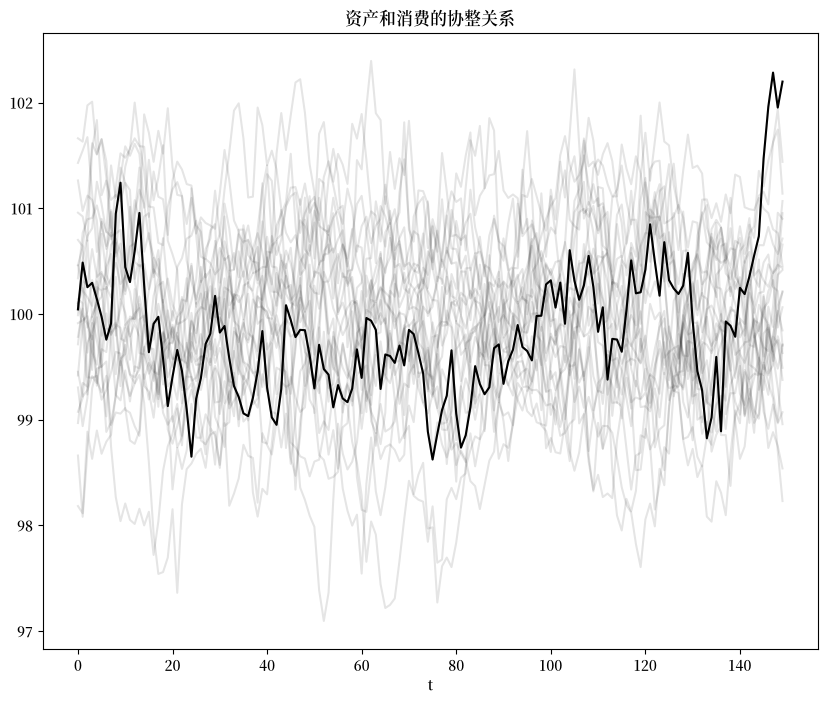

In [19]:
cointegration_figure(bsimb, csimb)
plt.show()